PART A: K-MEANS CLUSTERING


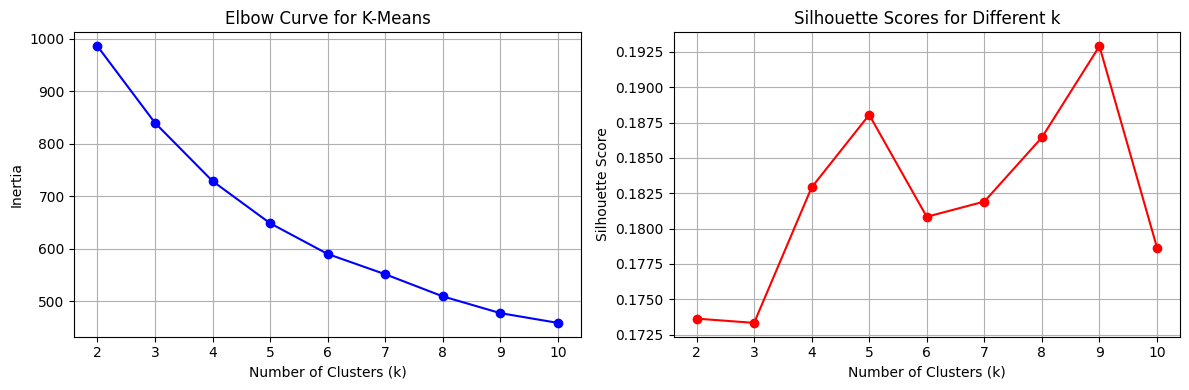

Optimal k based on silhouette score: 9


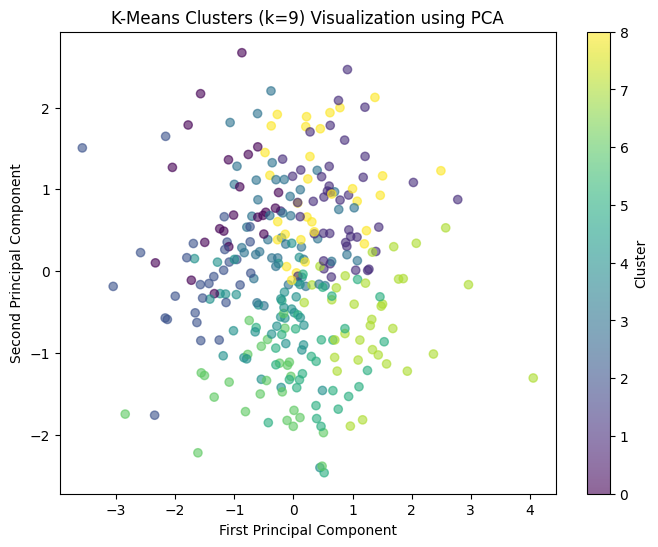


PART B: HIERARCHICAL CLUSTERING


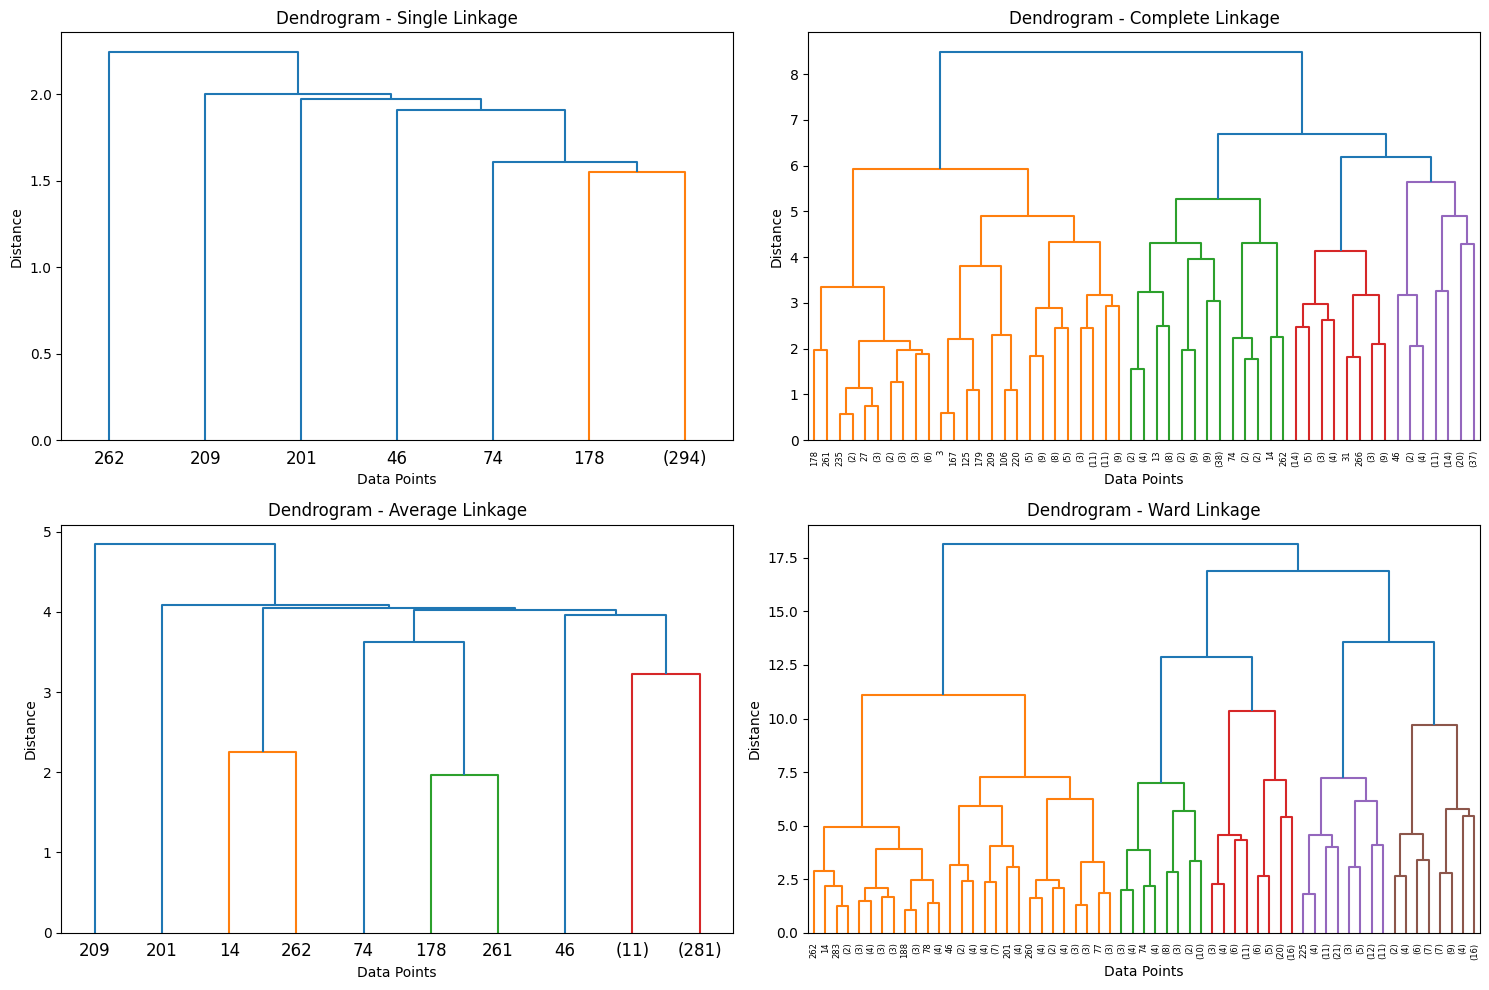

Single Linkage - Silhouette Score: 0.055
Complete Linkage - Silhouette Score: 0.120
Average Linkage - Silhouette Score: 0.005
Ward Linkage - Silhouette Score: 0.159


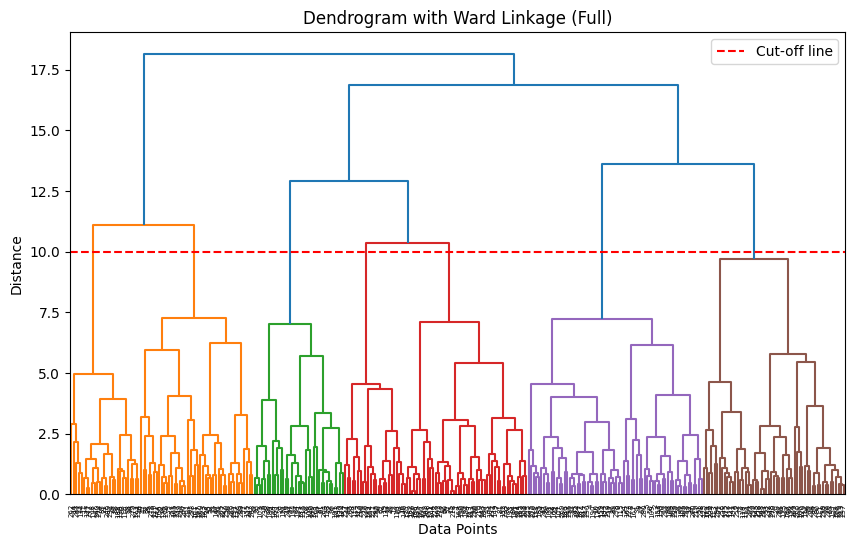


PART C: COMPARISON

Computation Time Comparison:
K-Means (k=9): 0.1214 seconds
Hierarchical (Ward, k=9): 0.0053 seconds

Cluster Characteristics Comparison:
----------------------------------------

K-Means Cluster Centers (Original Scale):
Cluster 0:
  Annual_Income: 47487.49
  Spending_Score: 46.14
  Age: 52.88
  Purchase_Frequency: 3.04
Cluster 1:
  Annual_Income: 53297.21
  Spending_Score: 19.92
  Age: 44.46
  Purchase_Frequency: 11.02
Cluster 2:
  Annual_Income: 39246.75
  Spending_Score: 78.65
  Age: 47.34
  Purchase_Frequency: 6.32
Cluster 3:
  Annual_Income: 33041.54
  Spending_Score: 42.55
  Age: 42.61
  Purchase_Frequency: 13.96
Cluster 4:
  Annual_Income: 46698.99
  Spending_Score: 38.14
  Age: 28.80
  Purchase_Frequency: 5.55
Cluster 5:
  Annual_Income: 69115.87
  Spending_Score: 65.10
  Age: 35.42
  Purchase_Frequency: 9.24
Cluster 6:
  Annual_Income: 42512.62
  Spending_Score: 82.88
  Age: 29.21
  Purchase_Frequency: 12.87
Cluster 7:
  Annual_Income: 62180.40
  Spending_

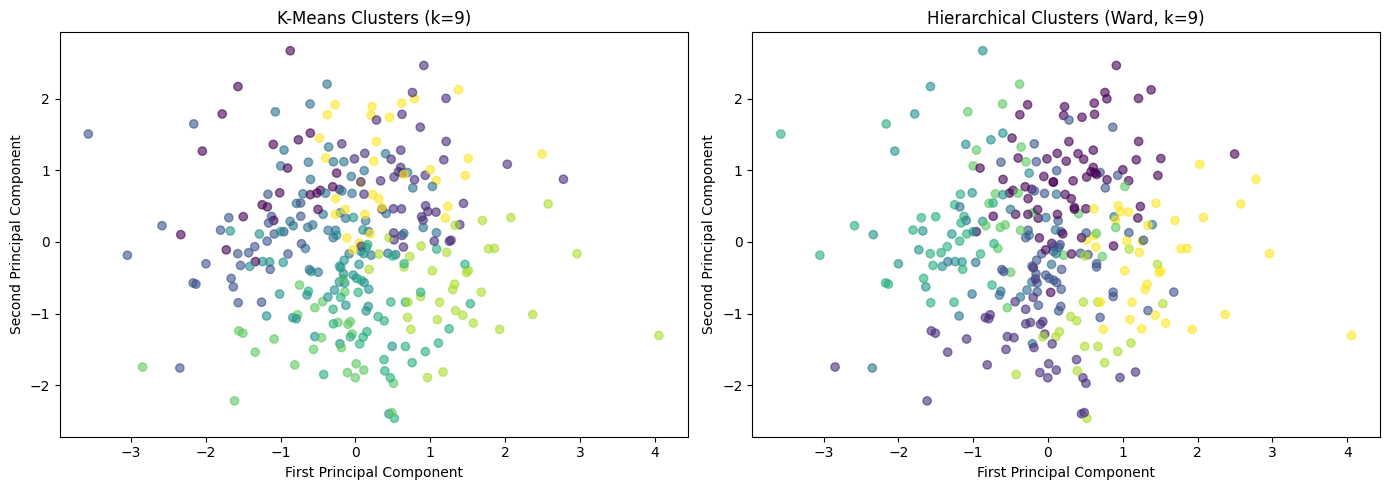


BUSINESS INTERPRETATION


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import time
import warnings
warnings.filterwarnings('ignore')

# Generate sample customer data (since we don't have actual dataset)
np.random.seed(42)
n_customers = 300

data = {
    'Annual_Income': np.random.normal(50000, 15000, n_customers),
    'Spending_Score': np.random.normal(50, 25, n_customers),
    'Age': np.random.normal(40, 12, n_customers),
    'Purchase_Frequency': np.random.normal(10, 5, n_customers)
}

df = pd.DataFrame(data)

# PART A: K-MEANS CLUSTERING
print("=" * 50)
print("PART A: K-MEANS CLUSTERING")
print("=" * 50)

# Preprocess and scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply K-Means with different k values (2-10)
k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-Means')
plt.grid(True)

# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.grid(True)

plt.tight_layout()
plt.show()

optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")

# Visualize clusters using PCA
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means Clusters (k={optimal_k}) Visualization using PCA')
plt.colorbar(label='Cluster')
plt.show()

# PART B: HIERARCHICAL CLUSTERING
print("\n" + "=" * 50)
print("PART B: HIERARCHICAL CLUSTERING")
print("=" * 50)

# Different linkage methods
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):

    linkage_matrix = linkage(X_scaled, method=method)

    dendrogram(linkage_matrix, ax=axes[idx], truncate_mode='level', p=5)

    axes[idx].set_title(f'Dendrogram - {method.capitalize()} Linkage')
    axes[idx].set_xlabel('Data Points')
    axes[idx].set_ylabel('Distance')

plt.tight_layout()
plt.show()

# Apply Agglomerative Clustering
for method in linkage_methods:

    agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage=method)

    agg_labels = agg_clustering.fit_predict(X_scaled)

    sil_score = silhouette_score(X_scaled, agg_labels)

    print(f"{method.capitalize()} Linkage - Silhouette Score: {sil_score:.3f}")

# Dendrogram with Ward linkage
linkage_matrix = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)

plt.title('Dendrogram with Ward Linkage (Full)')
plt.xlabel('Data Points')
plt.ylabel('Distance')

plt.axhline(y=10, color='r', linestyle='--', label='Cut-off line')

plt.legend()
plt.show()

# PART C: COMPARISON
print("\n" + "=" * 50)
print("PART C: COMPARISON")
print("=" * 50)

print("\nComputation Time Comparison:")

# K-Means time
start_time = time.time()

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_time = time.time() - start_time

print(f"K-Means (k={optimal_k}): {kmeans_time:.4f} seconds")

# Hierarchical time
start_time = time.time()

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_time = time.time() - start_time

print(f"Hierarchical (Ward, k={optimal_k}): {hierarchical_time:.4f} seconds")

# Compare cluster characteristics
print("\nCluster Characteristics Comparison:")
print("-" * 40)

df['KMeans_Cluster'] = kmeans_labels
df['Hierarchical_Cluster'] = hierarchical_labels

print("\nK-Means Cluster Centers (Original Scale):")

kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)

for i in range(optimal_k):
    print(f"Cluster {i}:")
    for j, col in enumerate(df.columns[:4]):
        print(f"  {col}: {kmeans_centers[i, j]:.2f}")

print("\nHierarchical Cluster Statistics:")

for i in range(optimal_k):

    cluster_data = df[df['Hierarchical_Cluster'] == i]

    print(f"\nCluster {i} (size: {len(cluster_data)}):")

    for col in df.columns[:4]:
        print(f"  {col} - Mean: {cluster_data[col].mean():.2f}, Std: {cluster_data[col].std():.2f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title(f'K-Means Clusters (k={optimal_k})')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.6)
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].set_title(f'Hierarchical Clusters (Ward, k={optimal_k})')

plt.tight_layout()
plt.show()

# Business interpretation
print("\n" + "=" * 50)
print("BUSINESS INTERPRETATION")
print("=" * 50)

   Annual_Income  Spending_Score        Age  Purchase_Frequency
0   57450.712295       29.275125  49.083863           11.843367
1   47926.035482       35.995474  28.934016            8.033306
2   59715.328072       68.682340  50.435271           10.143724
3   72845.447846       65.259257  56.267654           16.392259
4   46487.699379       49.477460  44.961219           10.955495

PART A : K-MEANS CLUSTERING


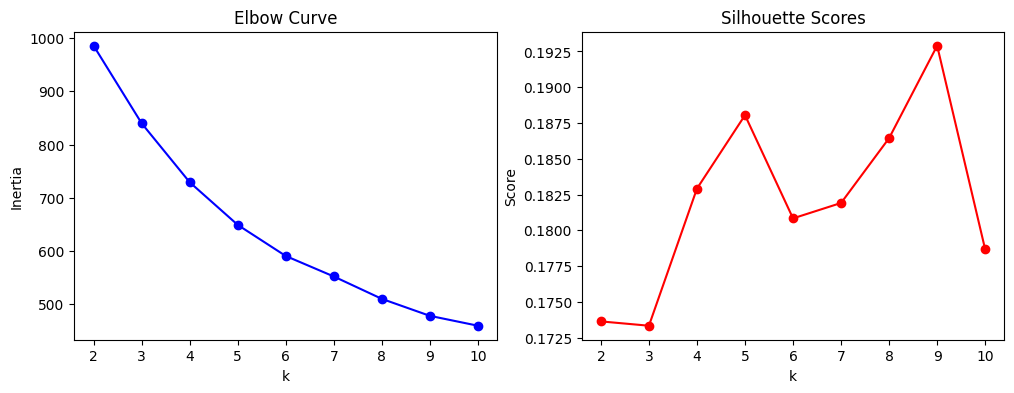

Optimal k: 9


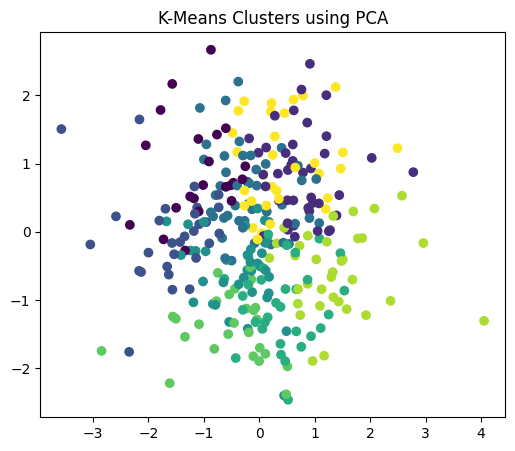


PART B : HIERARCHICAL CLUSTERING


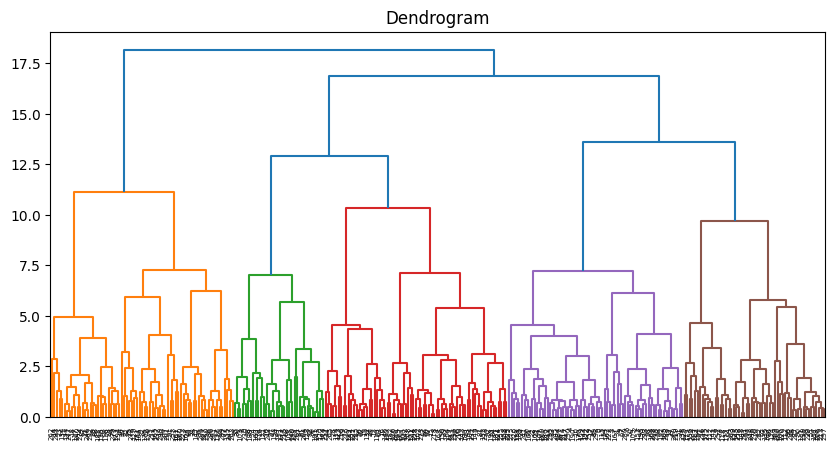


PART C : DBSCAN CLUSTERING
Clusters found: 2


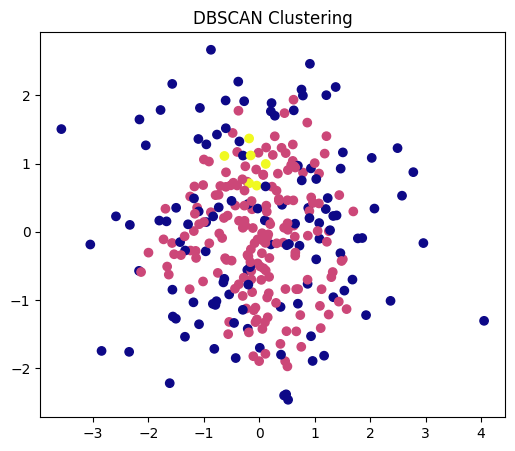


PART D : GAUSSIAN MIXTURE MODEL


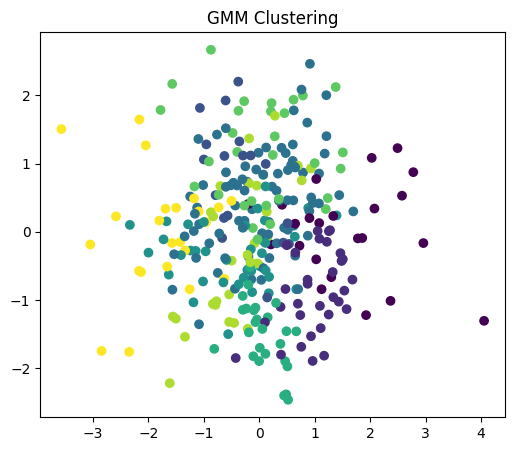


PART E : CLUSTER VALIDATION

 KMeans
Silhouette Score: 0.19290263418253636
Davies Bouldin: 1.329927096560253
Calinski Harabasz: 55.00904527923505

 Hierarchical
Silhouette Score: 0.15908791520875923
Davies Bouldin: 1.47391187933634
Calinski Harabasz: 46.12191141879335

 GMM
Silhouette Score: 0.09780261089964988
Davies Bouldin: 1.8280031307719529
Calinski Harabasz: 34.10113021840713

PART F : PCA BEFORE CLUSTERING


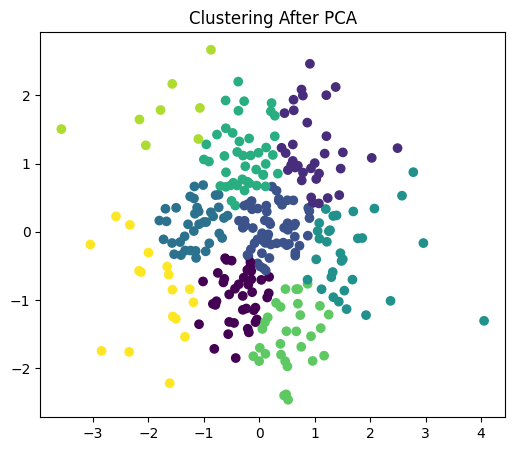


PART G : IMAGE SEGMENTATION


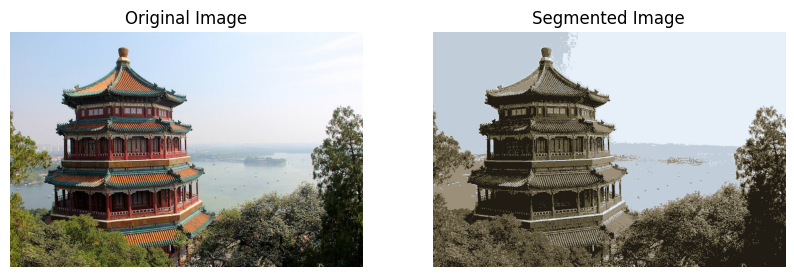


FINAL SUMMARY
Algorithms Implemented:
1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN Clustering
4. Gaussian Mixture Model
5. PCA Dimensionality Reduction
6. Image Segmentation using Clustering
7. Cluster Validation Metrics


In [3]:

# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import load_sample_image

warnings.filterwarnings('ignore')


# ============================================
# GENERATE SAMPLE CUSTOMER DATA
# ============================================

np.random.seed(42)

n_customers = 300

data = {
    'Annual_Income': np.random.normal(50000,15000,n_customers),
    'Spending_Score': np.random.normal(50,25,n_customers),
    'Age': np.random.normal(40,12,n_customers),
    'Purchase_Frequency': np.random.normal(10,5,n_customers)
}

df = pd.DataFrame(data)

print(df.head())


# ============================================
# DATA SCALING
# ============================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


# ============================================
# PART A : K-MEANS CLUSTERING
# ============================================

print("\n"+"="*50)
print("PART A : K-MEANS CLUSTERING")
print("="*50)

k_values = range(2,11)
inertias = []
sil_scores = []

for k in k_values:

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled,labels))


# ELBOW & SILHOUETTE GRAPH

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(k_values,inertias,'bo-')
plt.title("Elbow Curve")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(k_values,sil_scores,'ro-')
plt.title("Silhouette Scores")
plt.xlabel("k")
plt.ylabel("Score")

plt.show()

optimal_k = k_values[np.argmax(sil_scores)]

print("Optimal k:",optimal_k)


# FINAL KMEANS

kmeans = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)


# ============================================
# PCA VISUALIZATION
# ============================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0],X_pca[:,1],c=kmeans_labels,cmap='viridis')

plt.title("K-Means Clusters using PCA")
plt.show()


# ============================================
# PART B : HIERARCHICAL CLUSTERING
# ============================================

print("\n"+"="*50)
print("PART B : HIERARCHICAL CLUSTERING")
print("="*50)

linkage_matrix = linkage(X_scaled,method='ward')

plt.figure(figsize=(10,5))

dendrogram(linkage_matrix)

plt.title("Dendrogram")

plt.show()


hierarchical = AgglomerativeClustering(n_clusters=optimal_k,linkage='ward')

hierarchical_labels = hierarchical.fit_predict(X_scaled)


# ============================================
# PART C : DBSCAN CLUSTERING
# ============================================

print("\n"+"="*50)
print("PART C : DBSCAN CLUSTERING")
print("="*50)

dbscan = DBSCAN(eps=0.8,min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Clusters found:",n_clusters)


plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0],X_pca[:,1],c=dbscan_labels,cmap='plasma')

plt.title("DBSCAN Clustering")

plt.show()


# ============================================
# PART D : GAUSSIAN MIXTURE MODEL
# ============================================

print("\n"+"="*50)
print("PART D : GAUSSIAN MIXTURE MODEL")
print("="*50)

gmm = GaussianMixture(n_components=optimal_k,random_state=42)

gmm_labels = gmm.fit_predict(X_scaled)


plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0],X_pca[:,1],c=gmm_labels,cmap='viridis')

plt.title("GMM Clustering")

plt.show()


# ============================================
# PART E : CLUSTER VALIDATION METRICS
# ============================================

print("\n"+"="*50)
print("PART E : CLUSTER VALIDATION")
print("="*50)

methods = {
"KMeans":kmeans_labels,
"Hierarchical":hierarchical_labels,
"GMM":gmm_labels
}

for name,labels in methods.items():

    sil = silhouette_score(X_scaled,labels)
    db = davies_bouldin_score(X_scaled,labels)
    ch = calinski_harabasz_score(X_scaled,labels)

    print("\n",name)

    print("Silhouette Score:",sil)
    print("Davies Bouldin:",db)
    print("Calinski Harabasz:",ch)


# ============================================
# PART F : DIMENSIONALITY REDUCTION BEFORE CLUSTERING
# ============================================

print("\n"+"="*50)
print("PART F : PCA BEFORE CLUSTERING")
print("="*50)

pca2 = PCA(n_components=2)

X_reduced = pca2.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=optimal_k)

labels_pca = kmeans_pca.fit_predict(X_reduced)

plt.figure(figsize=(6,5))

plt.scatter(X_reduced[:,0],X_reduced[:,1],c=labels_pca,cmap='viridis')

plt.title("Clustering After PCA")

plt.show()


# ============================================
# PART G : IMAGE SEGMENTATION
# ============================================

print("\n"+"="*50)
print("PART G : IMAGE SEGMENTATION")
print("="*50)

china = load_sample_image("china.jpg")

X_img = np.reshape(china,(-1,3))

kmeans_img = KMeans(n_clusters=5,random_state=42)

kmeans_img.fit(X_img)

segmented = kmeans_img.cluster_centers_[kmeans_img.labels_]

segmented = segmented.reshape(china.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(china)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Segmented Image")
plt.imshow(segmented.astype(np.uint8))
plt.axis('off')

plt.show()


# ============================================
# FINAL SUMMARY
# ============================================

print("\n"+"="*50)
print("FINAL SUMMARY")
print("="*50)

print("Algorithms Implemented:")
print("1. K-Means Clustering")
print("2. Hierarchical Clustering")
print("3. DBSCAN Clustering")
print("4. Gaussian Mixture Model")
print("5. PCA Dimensionality Reduction")
print("6. Image Segmentation using Clustering")
print("7. Cluster Validation Metrics")

